In [2]:
import torch
import numpy as np
import tensorly
from tensorly.tenalg import multi_mode_dot
tensorly.set_backend('pytorch')
import matplotlib.pyplot as plt

In [3]:
def reconstruct_from_factors(factors: list[torch.Tensor]) -> torch.Tensor:
    
    if not factors:
        return torch.tensor([])
        
    #use einstein summation notation
    indices = [chr(97 + i) for i in range(len(factors))] 
    einsum_str = f"{','.join(indices)}->{''.join(indices)}"
    
    return torch.einsum(einsum_str, *factors)

def als_rank_one_approximation(B: torch.Tensor, max_iter: int = 10000, tol: float = 1e-8) -> list[torch.Tensor]:

    d = B.dim()
    dims = B.shape

    x_list = [torch.rand(dim) for dim in dims]
    
    # Normalisation
    for k in range(d):
        norm_val = torch.norm(x_list[k])
        if norm_val > 0:
            x_list[k] /= norm_val

    for _ in range(max_iter):
        x_list_old = [x.clone() for x in x_list]

        for k in range(d):
            
            # Solution of least squere problem is a tesordot of B and all vectors from x_list 
            update_vec = B
            modes_to_contract = sorted([m for m in range(d) if m != k], reverse=True)
            for mode in modes_to_contract:
                update_vec = torch.tensordot(update_vec, x_list[mode], dims=([mode], [0]))

            norm_val = torch.norm(update_vec)
            if norm_val > 0:
                x_list[k] = update_vec / norm_val
            else:
                x_list[k] = update_vec

        # max_change = max(torch.norm(x_list[k] - x_list_old[k]).item() for k in range(d))
        # if max_change < tol:
        #     break


    reconstruct_norm = reconstruct_from_factors(x_list)
    x_list[0] = torch.tensordot(B, reconstruct_norm, dims=B.dim()) * x_list[0]
    return x_list

In [ ]:
#Test ALS
A = torch.rand(10) 
B = torch.arange(1, 4) 
C = torch.arange(1, 5) 
original_tensor = torch.einsum('i,j,k->ijk', A, B, C)
print(original_tensor)


reconstructed = reconstruct_from_factors(als_rank_one_approximation(original_tensor))
print(reconstructed)
torch.norm(original_tensor - reconstructed)


In [ ]:
def gta( B: torch.Tensor, 
        error_tol: float = 1e-4, 
        max_rank: int = 50, 
        max_iter_als: int = 100, 
        tol_als: float = 1e-8
        ) -> tuple[list[torch.Tensor], torch.Tensor, int]:
    
    d = B.dim()
    norm_B = torch.norm(B)
    U = [torch.empty((B.shape[i], 0)) for i in range(d)]
    T = torch.zeros(B.shape)
    
    current_rank = 0
    current_error = 1.0 
    errors = []
    flag = 0
    while current_rank < max_rank:
        current_rank += 1
        
        x_list = als_rank_one_approximation(B - T, max_iter=max_iter_als, tol=tol_als)
        
        for j in range(d):
            new_vec = x_list[j]
            if U[j].shape[1] > 0:
                proj = torch.matmul(U[j], torch.matmul(U[j].T, new_vec))
                orth_vec = new_vec - proj
            else:
                orth_vec = new_vec
            norm = torch.norm(orth_vec)
            
            if norm > 1e-8:
                orth_vec /= norm
                U[j] = torch.cat([U[j], orth_vec.unsqueeze(1)], dim=1)

        if all(u.shape[1] > 0 for u in U):
            core_tensor = multi_mode_dot(B, [u.T for u in U])
            T = multi_mode_dot(core_tensor, U)
        
        
        current_error = torch.norm(B - T) / norm_B
        errors.append(current_error)

        if current_error > 1 and flag == 0:
            print(f"rank {current_rank} - first time error > 1")
            flag = 1
        if current_error < error_tol:
            break

    return U, core_tensor, current_rank, errors

In [5]:
def generate_low_tucker_rank_tensor(
    shape: tuple[int, ...], 
    rank: tuple[int, ...], 
    device=None
) -> tuple[torch.Tensor, torch.Tensor, list[torch.Tensor]]:
    """
    Генерирует тензор с заданным рангом Такера.

    Аргументы:
        shape (tuple): Желаемая форма выходного тензора (например, (20, 30, 40)).
        rank (tuple): Желаемый ранг Такера (например, (5, 6, 7)).
        device: Устройство для создания тензора ('cpu' или 'cuda').

    Возвращает:
        tuple:
            - Сгенерированный тензор низкого ранга.
            - Истинное ядро, использованное для генерации.
            - Список истинных фактор-матриц, использованных для генерации.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Генерируем случайные ортонормированные фактор-матрицы
    # Столбцы каждой матрицы U_i будут ортонормированным базисом
    factor_matrices = []
    for s, r in zip(shape, rank):
        # Создаем случайную матрицу и получаем ее ортонормированный базис через QR-разложение
        # Это гарантирует, что U.T @ U будет единичной матрицей
        q, _ = torch.linalg.qr(torch.randn(s, r, device=device))
        factor_matrices.append(q)
        
    # 2. Генерируем случайное ядро (core tensor)
    core_tensor = torch.randn(*rank, device=device)
    
    # 3. Собираем полный тензор через мульти-тензорное произведение
    low_rank_tensor = multi_mode_dot(core_tensor, factor_matrices)
    
    return low_rank_tensor, core_tensor, factor_matrices


Тестирование

1. Тензор с ядром одинаковых размеров по всем размерностям

Размеры матриц:
  U[0]: torch.Size([90, 30])
  U[1]: torch.Size([105, 30])
  U[2]: torch.Size([100, 30])
Размер ядра: torch.Size([30, 30, 30])
Итоговая ошибка: 0.000001


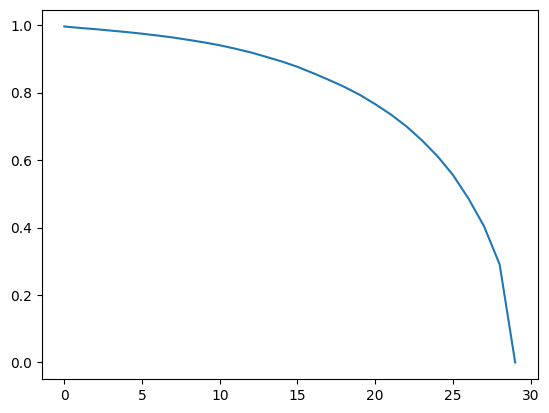

In [14]:
tensor_shape = (90, 105, 100)
tucker_rank = (30, 30, 30)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:40])))
plt.plot(x, errors[:40])
plt.show()

2. Если ядро немного не ровных размеров

rank 33 - first time error > 1
Размеры матриц:
  U[0]: torch.Size([90, 100])
  U[1]: torch.Size([100, 100])
  U[2]: torch.Size([105, 100])
Размер ядра: torch.Size([100, 100, 100])
Итоговая ошибка: 1132.049438


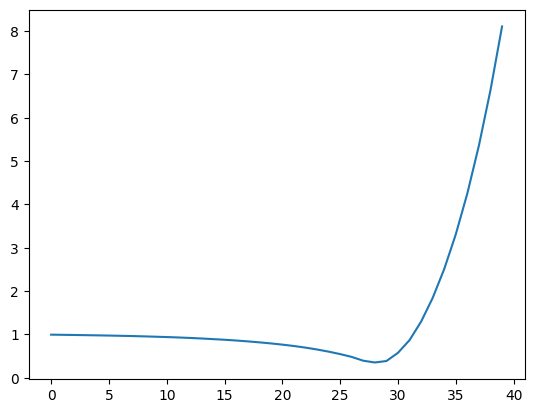

In [7]:
tensor_shape = (90, 100, 105)
tucker_rank = (32, 30, 28)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:40])))
plt.plot(x, errors[:40])
plt.show()

rank 13 - first time error > 1
Размеры матриц:
  U[0]: torch.Size([90, 100])
  U[1]: torch.Size([100, 100])
  U[2]: torch.Size([105, 100])
Размер ядра: torch.Size([100, 100, 100])
Итоговая ошибка: 3324.551025


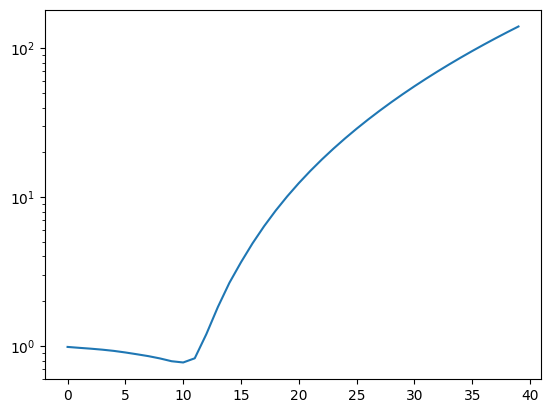

In [15]:
tensor_shape = (90, 100, 105)
tucker_rank = (42, 11, 10)
B, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:40])))
plt.plot(x, errors[:40])
plt.yscale('log')
plt.show()

3. Добавка шума

tensor(191.7010) tensor(165.1372)
Размеры матриц:
  U[0]: torch.Size([90, 100])
  U[1]: torch.Size([100, 100])
  U[2]: torch.Size([105, 100])
Размер ядра: torch.Size([100, 100, 100])
Итоговая ошибка: 1.071922


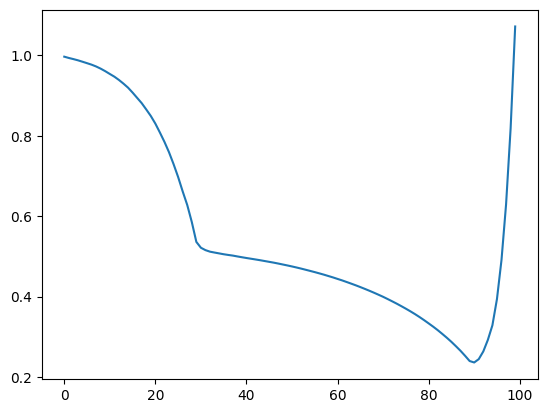

In [75]:
tensor_shape = (90, 100, 105)
tucker_rank = (30, 30, 30)
B_, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

B = B_ + 0.1 * torch.randn_like(B_)
print(torch.norm(B), torch.norm(B_))

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:100])))
plt.plot(x, errors[:100])
plt.show()

Кажется, что первый излом графика происходит примерно в там, где находится ранг. Возможно, это получится использовать как эвристику для поиска коэффициента сжатия


tensor(188.1190) tensor(161.0632)
Размеры матриц:
  U[0]: torch.Size([90, 100])
  U[1]: torch.Size([100, 100])
  U[2]: torch.Size([105, 100])
Размер ядра: torch.Size([100, 100, 100])
Итоговая ошибка: 1.139897


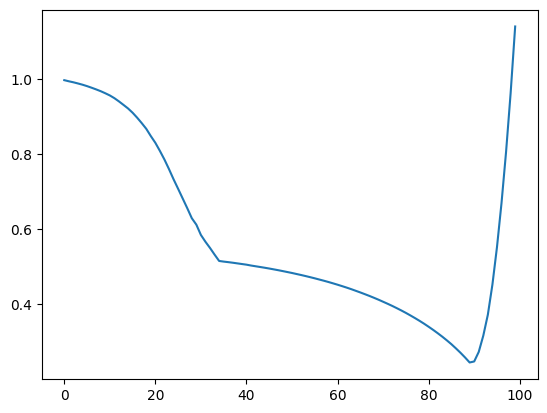

In [74]:
tensor_shape = (90, 100, 105)
tucker_rank = (35, 30, 25)
B_, _, __, = generate_low_tucker_rank_tensor(tensor_shape, tucker_rank)

B = B_ + 0.1 * torch.randn_like(B_)
print(torch.norm(B), torch.norm(B_))

factor_matrices, core_tensor, final_rank, errors = gta(B, max_rank=100, max_iter_als=100, error_tol=0.01)


print("Размеры матриц:")
for i, u_matrix in enumerate(factor_matrices):
    print(f"  U[{i}]: {u_matrix.shape}")
print(f"Размер ядра: {core_tensor.shape}")

reconstructed_B = multi_mode_dot(core_tensor, factor_matrices)
final_error_check = torch.norm(B - reconstructed_B) / torch.norm(B)
print(f"Итоговая ошибка: {final_error_check.item():.6f}")


x = list(range(0, len(errors[:100])))
plt.plot(x, errors[:100])
plt.show()